<!-- [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VectorInstitute/interpretability/blob/main/implementations/Post-hoc/SHAP/shap-nn-jupyter.ipynb)
 -->
# SHAP for Neural Network Models

## **1. Introduction**

SHAP is model-agnostic and can be used to explain other black box models as well, for example, neural networks.
The shap module in python has something called KernelExplainer which can be used for NNs.

Let's illustrate this using a [Credit Card Defaulter dataset from Taiwan](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

The dataset has the following 23 variables as explanatory variables:
| Variable | Description |
|----------|------------|
| LIMIT_BAL  | Amount of the given credit (NT dollar): includes both individual consumer credit and family (supplementary) credit. |
| SEX  | Gender (1 = male; 2 = female). |
| EDUCATION  | Education (1 = graduate school; 2 = university; 3 = high school; 4 = others). |
| MARRIAGE  | Marital status (1 = married; 2 = single; 3 = others). |
| AGE  | Age (years). |
| PAY_0  | Repayment status in September 2005 (-1 = pay duly; 1 = delay for 1 month; 2 = delay for 2 months; ...; 8 = delay for 8 months; 9 = delay for 9+ months). |
|  PAY_2 | Repayment status in August 2005. |
| PAY_3  | Repayment status in July 2005. |
| PAY_4  | Repayment status in June 2005. |
| PAY_5 | Repayment status in May 2005. |
| PAY_6 | Repayment status in April 2005. |
| BILL_AMT1 | Amount of bill statement (NT dollar) in September 2005. |
| BILL_AMT2 | Amount of bill statement (NT dollar) in August 2005. |
| BILL_AMT3 | Amount of bill statement (NT dollar) in July 2005. |
| BILL_AMT4 | Amount of bill statement (NT dollar) in June 2005. |
| BILL_AMT5 | Amount of bill statement (NT dollar) in May 2005. |
| BILL_AMT6 | Amount of bill statement (NT dollar) in April 2005. |
| PAY_AMT1 | Amount of previous payment (NT dollar) in September 2005. |
| PAY_AMT2 | Amount of previous payment (NT dollar) in August 2005. |
| PAY_AMT3 | Amount of previous payment (NT dollar) in July 2005. |
| PAY_AMT4 | Amount of previous payment (NT dollar) in June 2005. |
| PAY_AMT5 | Amount of previous payment (NT dollar) in May 2005. |
| PAY_AMT6 | Amount of previous payment (NT dollar) in April 2005. |

## **2. Import the necessary libraries**

In [3]:
import numpy as np
import pandas as pd
import shap
import torch
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset


np.random.seed(1)

## **3. Loading the dataset**

In [ ]:
# !curl -o data/clients.zip https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip
# !unzip -o data/clients.zip -d data
# !rm data/clients.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 5409k    0 5409k    0     0  7147k      0 --:--:-- --:--:-- --:--:-- 7146k
Archive:  data/clients.zip
 extracting: data/default of credit card clients.xls  


In [4]:
# Load the data
data = pd.read_excel(
    "data/default of credit card clients.xls",
    header=1,
)
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## **4. Create a PyTorch dataset**
Create a dataset class inherited from PyTorch Dataset to be input for model training.

In [5]:
# Load dataset
X = data.drop(["default payment next month", "ID"], axis=1)
y = data["default payment next month"]

# Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
y_train = y_train.values  # Convert pandas series to NumPy array
y_test = y_test.values


# Create a PyTorch Dataset
class CreditDataset(Dataset):
    """PyTorch Dataset for Credit data."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # Reshape y to be column vector

    def __len__(self):
        """Return dataset length."""
        return len(self.X)

    def __getitem__(self, idx):
        """Get item at index."""
        return self.X[idx], self.y[idx]


# Create DataLoaders for batching
batch_size = 64
train_dataset = CreditDataset(X_train, y_train)
test_dataset = CreditDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## **5. Train a 3-layer MLP using PyTorch**
Let's train a simple 3-layer MLP to predict credit card defaults.

Epoch [10/125], Loss: 0.4304
Epoch [20/125], Loss: 0.4228
Epoch [30/125], Loss: 0.4194
Epoch [40/125], Loss: 0.4137
Epoch [50/125], Loss: 0.4112
Epoch [60/125], Loss: 0.4077
Epoch [70/125], Loss: 0.4055
Epoch [80/125], Loss: 0.4026
Epoch [90/125], Loss: 0.4008
Epoch [100/125], Loss: 0.3973
Epoch [110/125], Loss: 0.3964
Epoch [120/125], Loss: 0.3931
Accuracy: 0.8115
ROC AUC Score: 0.7657


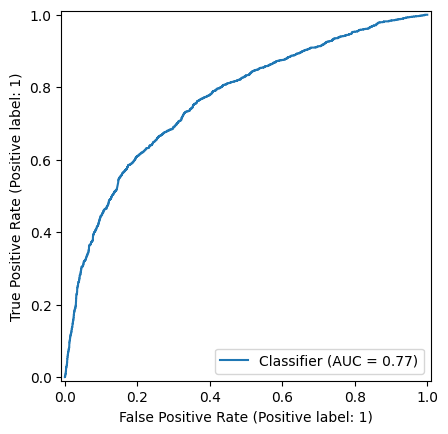

In [6]:
# Define the model
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model in batches
num_epochs = 125
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Print average loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate the model
model.eval()  # Set model to evaluation mode
y_pred_probs = []
y_true = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        y_pred_probs.extend(outputs.numpy())  # Store predictions
        y_true.extend(batch_y.numpy())  # Store true labels

# Convert predictions to NumPy array
y_pred_probs = np.array(y_pred_probs).flatten()
y_true = np.array(y_true).flatten()

# Compute accuracy
accuracy = ((y_pred_probs > 0.5) == y_true).mean()
print(f"Accuracy: {accuracy:.4f}")

# Compute ROC AUC score
roc_auc = roc_auc_score(y_true, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_true, y_pred_probs)

## **5a. Train Model using different Algorithms**
Consider Logistic, KNN, XGboost and ANN

In [17]:
# Sclable Logistic Regression
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, n_jobs=-1)

batch_size = 1000 # Batch size
for start in range(0, len(X_train), batch_size):
    end = min(start + batch_size, len(X_train))
    sgd.partial_fit(X_train[start:end], y_train[start:end], classes=[0, 1])

y_pred = sgd.predict(X_test)
auc = roc_auc_score(y_test, sgd.decision_function(X_test))
print(f"SGD Logistic Regression AUC: {auc:.3f}")

accuracy = ((y_pred > 0.5) == y_test).mean()
print(f"Accuracy: {accuracy:.4f}")

SGD Logistic Regression AUC: 0.688
Accuracy: 0.7640


In [18]:

# KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', leaf_size=40, n_jobs=-1)
knn.fit(X_train, y_train)

y_pred_proba = knn.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"KNN AUC: {auc:.3f}")

accuracy = ((y_pred_proba > 0.5) == y_test).mean()
print(f"Accuracy: {accuracy:.4f}")

KNN AUC: 0.708
Accuracy: 0.7950


In [20]:

# XGBoost
import xgboost as xgb

xgb_classifer = xgb.XGBClassifier(objective='binary:logistic')
model = xgb_classifer.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba[:,1])
print(f"XGBoost AUC: {auc:.3f}")

accuracy = ((y_pred_proba[:,1] > 0.5) == y_test).mean()
print(f"Accuracy: {accuracy:.4f}")

XGBoost AUC: 0.775
Accuracy: 0.8148


In [22]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

model.fit(X_train, y_train, epochs=125, batch_size=64, validation_split=0.1, verbose=0)

y_prob = model.predict(X_test).ravel()
auc = roc_auc_score(y_test, y_prob)
print(f"Neural Network AUC: {auc:.3f}")

accuracy = ((y_prob > 0.5) == y_test).mean()
print(f"Accuracy: {accuracy:.4f}")

/home/coder/interpretability-llms-agents/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Neural Network AUC: 0.742
Accuracy: 0.8025


## **5b. Train Model using different Algorithms**
Train a XGBoost Model with fine tuning

In [ ]:
# pip install optuna

In [33]:
from xgboost import XGBClassifier
import optuna

# Set up k-fold cross-validation
k_folds = 10
kf = StratifiedKFold(n_splits=k_folds, shuffle=False, random_state=None)

def objective(trial):
    # Define the hyperparameter search space
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 10), # Depth of trees
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # Learning Rate
        'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Number of trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # Min child weight
        'gamma': trial.suggest_float('gamma', 0.0, 5.0), # Minimum loss reduction
        'subsample': trial.suggest_float('subsample', 0.5, 1.0), # Row sampling
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0) # Column sampling
    }

    auc_scores = []

    for train_idx, test_idx in kf.split(X_train, y_train):
        X_train_fold, X_test_fold = X_train[train_idx], X_train[test_idx]
        y_train_fold, y_test_fold = y_train[train_idx], y_train[test_idx]

        # Train XGBoost model
        model = XGBClassifier(**param, objective='binary:logistic', eval_metric='auc')
        model.fit(X_train_fold, y_train_fold)

        # Evaluate on validation set
        y_val_pred_proba = model.predict_proba(X_test_fold)[:, 1]
        auc = roc_auc_score(y_test_fold, y_val_pred_proba)
        auc_scores.append(auc)

    # Return the metric to maximize (validation auc)
    return np.mean(auc_scores)

study = optuna.create_study(direction='maximize') # Maximize auc
study.optimize(objective, n_trials=30, n_jobs=-1) # Run for 30 trials

print("\nBest hyperparameters:", study.best_params)
print("Best AUC:", study.best_value)

[I 2026-04-21 22:08:26,623] A new study created in memory with name: no-name-29ba6d8b-243f-43bb-8db8-88c01af3b723


[I 2026-04-21 22:08:34,150] Trial 0 finished with value: 0.7841378379547775 and parameters: {'max_depth': 9, 'learning_rate': 0.0246401981250651, 'n_estimators': 63, 'min_child_weight': 10, 'gamma': 1.2296023770238445, 'subsample': 0.6062227738542885, 'colsample_bytree': 0.7100778605464633}. Best is trial 0 with value: 0.7841378379547775.
[I 2026-04-21 22:08:41,794] Trial 1 finished with value: 0.7840627507989015 and parameters: {'max_depth': 10, 'learning_rate': 0.03256693883793896, 'n_estimators': 117, 'min_child_weight': 8, 'gamma': 0.4047300717335578, 'subsample': 0.5449452389019073, 'colsample_bytree': 0.8097164885787862}. Best is trial 0 with value: 0.7841378379547775.
[I 2026-04-21 22:08:43,241] Trial 2 finished with value: 0.7823373444012808 and parameters: {'max_depth': 3, 'learning_rate': 0.029181594662494644, 'n_estimators': 259, 'min_child_weight': 8, 'gamma': 3.45947487795694, 'subsample': 0.57175284381102, 'colsample_bytree': 0.5381221084498817}. Best is trial 0 with valu


Best hyperparameters: {'max_depth': 7, 'learning_rate': 0.019029274654511593, 'n_estimators': 489, 'min_child_weight': 7, 'gamma': 2.8256555557502576, 'subsample': 0.8932218436523258, 'colsample_bytree': 0.5590710152931371}
Best AUC: 0.7857715202162092


In [8]:
from xgboost import XGBClassifier

best_params = {'max_depth': 7, 'learning_rate': 0.019029274654511593, 'n_estimators': 489, 'min_child_weight': 7, 'gamma': 2.8256555557502576, 'subsample': 0.8932218436523258, 'colsample_bytree': 0.5590710152931371}

final_model = XGBClassifier(**best_params, objective='binary:logistic', eval_metric='auc', random_state=36)

# Train on train set
final_model.fit(X_train, y_train)

# Evaluate on test set
y_test_pred_proba = final_model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_test_pred_proba[:,1])
print(f"Final AUC on TEST: {auc: .3f}")

accuracy = ((y_test_pred_proba[:,1] > 0.5) == y_test).mean()
print(f"Accuracy: {accuracy:.4f}")

Final AUC on TEST:  0.784
Accuracy: 0.8207


## **6. Use SHAP to explain Neural network predictions**

In [1]:
# Use existing NumPy arrays
X_train_np = X_train
X_test_np = X_test

# Reduce background dataset for SHAP (using 200 samples instead of full training set)
background = shap.kmeans(X_train_np, 200)


# # Wrapper function for PyTorch model inference
# def model_wrapper(data):
#     """Model wrapper for SHAP."""
#     with torch.no_grad():
#         data_tensor = torch.tensor(data, dtype=torch.float32)
#         return model(data_tensor).detach().numpy()
#         # Should be (n_samples, n_classes)



# Wrapper function for the XGBClassifier model
def model_wrapper(data):
    """Model wrapper for SHAP."""
    return final_model.predict_proba(data)

# Use KernelExplainer with reduced background
explainer = shap.KernelExplainer(model_wrapper, background)

# Explain only a small subset of the test set (e.g., 50 samples)
X_test_sample = X_test_np[:50]


# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

print("X_test_sample shape:", X_test_sample.shape)  # Should be (n_samples, n_features)
print("SHAP values shape:", np.array(shap_values).shape)  # Should match (n_samples, n_features)

# Remove extra dimension if shap_values is (50, 23, 1)
shap_values = np.array(shap_values)  # Convert to NumPy array
if shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)  # Remove last dimension

# Ensure correct shape
print("Updated SHAP values shape:", shap_values.shape)  # Should be (50, 23)


# Generate SHAP summary plot
shap.summary_plot(shap_values, X_test_sample, feature_names=data.columns[1:-1])

NameError: name 'X_train' is not defined

1. **What Do the Axes Mean?**
	-	Y-axis (Feature Names): Lists the most important features from top to bottom, ranked by their impact on the model’s predictions.

	-	X-axis (SHAP Value): Represents the impact of each feature on the model’s prediction.

	-	A positive SHAP value increases the probability of default.

	-	A negative SHAP value decreases the probability of default.

2. **What Do the Colors Mean?**
   
	-	Red: High feature value (e.g., high credit limit, high bill amount, etc.)

	-	Blue: Low feature value (e.g., low credit limit, low bill amount, etc.)

	-	Purple: Intermediate values.

    - If a red dot is positioned to the right, it means that a higher value of that feature increases the default risk. If it’s on the left, it decreases the risk.

3. The top-ranked features contribute the most to the model’s prediction. In this case:

	-	**PAY_0 (Repayment Status for the Most Recent Month):**
		- The most significant predictor of default.
		- Higher values (more delayed payments) strongly increase default probability (red dots shift to the right).
	 	-  Lower values (on-time payments) reduce the risk (blue dots shift left).
  
	-	**LIMIT_BAL (Credit Limit Amount):**
		- Higher credit limits seem to reduce the risk of default (red dots slightly shift left).
		-	Lower credit limits are more associated with default risk.

	-	**BILL_AMT4, BILL_AMT1, BILL_AMT6 (Bill Amounts for Different Months):**
		-	Large bill amounts have mixed impact, depending on other factors.
		-	Higher bills (red) sometimes increase default risk but not always.

	-	**PAY_4, PAY_3, PAY_2, PAY_5, PAY_6 (Previous Payment Statuses):**
		-	Late payments from earlier months also contribute to default risk.
		-	Pattern: More delays → Higher SHAP values → More risk.

4. Lesser Impact Features
   
	-	**SEX, AGE, MARRIAGE, EDUCATION:**
		-	These have much lower SHAP values, meaning they don’t significantly influence predictions.
		-	Some impact exists, but it’s much weaker than repayment history.

Credits: This notebook is taken from the [Vector Institute's 2025 Bootcamp on Interpretable and Explainable AI.](https://github.com/VectorInstitute/interpretability/tree/main)

# Reflection & Concept Check

#### 1. Thought Experiment

**How might correlated features affect SHAP interpretations?**

**Answer:**

KernelSHAP approximates Shapley values by sampling feature coalitions and implicitly assumes feature independence when marginalizing missing features.
If features are correlated (e.g., `BILL_AMT1–6`):

* Importance may be **distributed across correlated features**
* Attribution may appear diluted
* Removing one correlated feature may not change prediction much (since others substitute)

This can:

* Underestimate true causal importance
* Make rankings unstable
* Produce misleading interpretations

In financial datasets, repayment and bill history are strongly correlated, so SHAP values reflect predictive contribution under independence assumptions, not causal effect.


#### 2️. Challenge

**If you removed repayment features (`PAY_*`), what would happen to SHAP importance rankings?**

**Answer:**

Likely outcomes:

* `BILL_AMT*` and `LIMIT_BAL` would become more important.
* Demographic features might slightly increase in relative importance.
* Overall model performance (ROC AUC) would drop.

Reason:

Repayment history is the strongest predictive signal of default.
Without it, the model must rely on weaker proxies (bill amounts, credit limit).

This tests whether the model is:

* Truly learning risk patterns
* Or heavily dependent on short-term delinquency signals


#### 3️. Thought Experiment

**If background size is reduced from 200 → 20, what changes?**

**Answer:**

* Runtime decreases significantly.
* Variance of SHAP values increases.
* Summary plot may become noisier.
* Individual explanations become less stable.

Because SHAP approximates expectations over background data, fewer background samples → less accurate estimation of the expected value.


#### 4️. Challenge

**If SHAP value for `PAY_0` is +0.15, what does that mean numerically?**

**Answer:**

SHAP decomposes:

$\text{Model output} = \text{expected value} + \sum_i \phi_i$

If:

* Expected prediction = 0.32 (baseline probability)
* SHAP(PAY_0) = +0.15

Then:

PAY_0 contributes +0.15 to the predicted probability relative to the expected prediction (baseline), holding other feature contributions additive.

So prediction becomes:

$0.32 + 0.15 + \text{(other feature contributions)}$

It is not a “risk score” — it is an additive contribution relative to baseline.


#### 5️. Thought Experiment

**If you removed the sigmoid layer and computed SHAP on logits instead, what changes?**

**Answer:**

* SHAP values become additive in log-odds space (which is linear before the sigmoid transformation).
* Interpretations become more linear and stable.
* Contributions no longer bounded between 0 and 1.

Explaining logits is often mathematically cleaner because:

$\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$

Additive decompositions are more natural before nonlinear squashing.

## References:
1. SHAP Documentation: [https://shap.readthedocs.io/en/latest/](https://shap.readthedocs.io/en/latest/)
2. SHAP in Interpretable Machine Learning Book: [https://christophm.github.io/interpretable-ml-book/shap.html](https://christophm.github.io/interpretable-ml-book/shap.html)
3. SHAP Original Paper: Lundberg, Scott M., and Su-In Lee. "A unified approach to interpreting model predictions." Advances in neural information processing systems 30 (2017). Link: [https://arxiv.org/abs/1705.07874](https://arxiv.org/abs/1705.07874)